# PCA Detector Explainability

This notebook explains the frozen AeroXAI PCA anomaly detector selected in Phase 2.

It answers four questions:
- Which engineered features contributed most strongly to each anomaly?
- Which operator-level sensor groups dominated each documented incident alert?
- How did incident-linked alerts differ from benchmark-false alerts?
- What can the explanation support, and what can it not support?

For test bin $t$ and feature $j$, the raw PCA contribution is:

$$
c_{t,j}
=
\frac{(x_{t,j}-\hat{x}_{t,j})^2}{d}
$$

so the raw PCA anomaly score is:

$$
r_t
=
\sum_j c_{t,j}
$$

AeroXAI then propagates each feature contribution through the same causal EWMA used by the alert pipeline:

$$
C_{t,j}
=
\alpha c_{t,j}
+
(1-\alpha)C_{t-1,j}
$$

Therefore the smoothed alert score is:

$$
S_t
=
\sum_j C_{t,j}
$$

A high contribution means that a signal contributed strongly to the anomaly score. It does **not** establish physical causality or confirmed root cause.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()

if not (ROOT / "ml").exists() and (ROOT.parent / "ml").exists():
    ROOT = ROOT.parent

if not (ROOT / "ml").exists():
    raise RuntimeError(
        "Could not locate the xAI-Compressor repository root."
    )

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print(f"Repository root: {ROOT}")

Repository root: /mnt/c/Users/Dell ProMax Tower T2/Downloads/code/xAI-Compressor


## Load configuration and reusable modules

In [2]:
import json
from typing import Any

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

from ml.data.features import model_feature_columns
from ml.detection.alerts import (
    causal_ewma,
    extract_alert_episodes,
    persistent_alerts,
)
from ml.detection.pca_detector import (
    fit_pca_detector,
    score_pca_detector,
)
from ml.explainability.pca import (
    aggregate_contributions,
    causal_ewma_contributions,
    explain_pca_detector,
)

METROPT_CONFIG_PATH = ROOT / "configs" / "metropt.yaml"
DETECTION_CONFIG_PATH = ROOT / "configs" / "detection.yaml"
REPORT_PATH = ROOT / "docs" / "xai_report.json"

with METROPT_CONFIG_PATH.open("r", encoding="utf-8") as handle:
    metropt = yaml.safe_load(handle)

with DETECTION_CONFIG_PATH.open("r", encoding="utf-8") as handle:
    detection = yaml.safe_load(handle)

preprocessing = metropt["preprocessing"]
incidents = metropt["dataset"]["reported_incidents"]

alert_config = detection["alerting"]
evaluation_config = detection["evaluation"]
pca_config = detection["pca"]
selection_config = detection["selection"]

if selection_config["primary"] != "pca_reconstruction":
    raise ValueError(
        "This notebook explains the PCA primary detector, "
        "but configs/detection.yaml selects a different model."
    )

print("Primary detector:", selection_config["primary"])

Primary detector: pca_reconstruction


## Load the frozen train, calibration, and test partitions

In [3]:
def load_partition(path: Path) -> pd.DataFrame:
    frame = pd.read_parquet(path)
    frame.index = pd.DatetimeIndex(
        frame.index,
        name="timestamp",
    )
    return frame.sort_index()

def row_at_timestamp(
    frame: pd.DataFrame,
    timestamp: pd.Timestamp,
) -> pd.Series:
    row = frame.loc[timestamp]

    if isinstance(
        row,
        pd.DataFrame,
    ):
        raise TypeError(
            "Expected exactly one row at "
            f"{timestamp}, but found multiple rows."
        )

    return row.astype(float)

train = load_partition(ROOT / preprocessing["train_file"])
calibration = load_partition(ROOT / preprocessing["calibration_file"])
test = load_partition(ROOT / preprocessing["test_file"])

feature_columns = model_feature_columns(train.columns)

pd.DataFrame(
    {
        "rows": [len(train), len(calibration), len(test)],
        "start": [
            train.index.min(),
            calibration.index.min(),
            test.index.min(),
        ],
        "end": [
            train.index.max(),
            calibration.index.max(),
            test.index.max(),
        ],
    },
    index=["train", "calibration", "test"],
)

,rows,start,end
train,5271,2020-02-01 00:05:00,2020-02-21 23:55:00
calibration,1796,2020-02-22 01:00:00,2020-02-28 23:55:00
test,43221,2020-03-01 04:05:00,2020-09-01 03:55:00


## Refit the frozen PCA detector

The detector is reproduced from the training partition only. The variance-retention setting comes from `configs/detection.yaml`.

In [4]:
variance_retained = float(pca_config["variance_retained"])

detector = fit_pca_detector(
    train,
    feature_columns,
    variance_retained=variance_retained,
)

print("PCA components:", int(detector.model.n_components_))
print(
    "Explained training variance:",
    float(detector.model.explained_variance_ratio_.sum()),
)

PCA components: 3
Explained training variance: 0.9716022727986392


## Reproduce the Phase 2 alert pipeline

The threshold is calibrated on the calibration partition only. Incident labels are not used to choose it.

In [5]:
calibration_raw = score_pca_detector(
    calibration,
    detector,
)

calibration_smoothed = causal_ewma(
    calibration_raw,
    alpha=float(alert_config["ewma_alpha"]),
    reset_gap_minutes=int(alert_config["reset_gap_minutes"]),
)

threshold = float(
    calibration_smoothed.quantile(
        float(alert_config["threshold_quantile"]),
        interpolation="higher",
    )
)

test_raw = score_pca_detector(
    test,
    detector,
)

test_smoothed = causal_ewma(
    test_raw,
    alpha=float(alert_config["ewma_alpha"]),
    reset_gap_minutes=int(alert_config["reset_gap_minutes"]),
)

_, alerts = persistent_alerts(
    test_smoothed,
    threshold=threshold,
    required_hits=int(alert_config["persistence_hits"]),
    window_bins=int(alert_config["persistence_window"]),
    reset_gap_minutes=int(alert_config["reset_gap_minutes"]),
)

episodes = extract_alert_episodes(
    alerts,
    merge_minutes=int(alert_config["merge_minutes"]),
    reset_gap_minutes=int(alert_config["reset_gap_minutes"]),
)

print(f"PCA threshold: {threshold:.6f}")
print(f"Alert bins: {int(alerts.sum()):,}")
print(f"Alert episodes: {len(episodes):,}")

PCA threshold: 52941.884488
Alert bins: 3,263
Alert episodes: 142


## Compute exact smoothed alert-score contributions

`explain_pca_detector()` first decomposes the raw PCA reconstruction score into non-negative engineered-feature contributions.

Those contributions are then propagated through the same causal EWMA used by the Phase 2 alert pipeline. The resulting smoothed contributions therefore sum to the actual smoothed PCA alert score.

Engineered feature statistics such as `tp2__mean`, `tp2__std`, and `tp2__max` are also aggregated into operator-level signal groups such as `tp2`.

In [6]:
explanation = explain_pca_detector(
    test, detector,
)

raw_feature_contributions = explanation.contributions

smoothed_feature_contributions = (
    causal_ewma_contributions(
        raw_feature_contributions,
        alpha=float(alert_config["ewma_alpha"]),
        reset_gap_minutes=int(
            alert_config[
                "reset_gap_minutes"
            ]
        ),
    )
)

smoothed_feature_total = (
    smoothed_feature_contributions
    .sum(axis=1)
    .replace(0.0, np.nan)
)

normalized_smoothed_feature_contributions = (
    smoothed_feature_contributions
    .div(
        smoothed_feature_total,
        axis=0,
    )
    .fillna(0.0)
)

smoothed_group_contributions = (
    aggregate_contributions(
        smoothed_feature_contributions
    )
)

smoothed_group_total = (
    smoothed_group_contributions
    .sum(axis=1)
    .replace(0.0, np.nan)
)

normalized_smoothed_group_contributions = (
    smoothed_group_contributions
    .div(
        smoothed_group_total,
        axis=0,
    )
    .fillna(0.0)
)

reconstructed_smoothed_score = (
    smoothed_feature_contributions.sum(axis=1)
)

max_difference = float(
    (
        reconstructed_smoothed_score - test_smoothed
    )
    .abs().max()
)

tolerance = (
    max(
        1.0,
        float(test_smoothed.abs().max()),
    )
    * 1.0e-10
)

if max_difference > tolerance:
    raise ValueError(
        "Smoothed feature contributions "
        "do not reconstruct the alert score. "
        f"Maximum difference: {max_difference}"
    )

print(
    "Engineered feature contributions:",
    smoothed_feature_contributions.shape[1],
)

print(
    "Operator-level signal groups:",
    smoothed_group_contributions.shape[1],
)

print(
    "Maximum XAI/score difference:",
    max_difference,
)

Engineered feature contributions: 63
Operator-level signal groups: 16
Maximum XAI/score difference: 2.9103830456733704e-10


## Test-period context

The alert pipeline uses the **smoothed** PCA score. The contribution tables below explain that same smoothed score by propagating the raw PCA feature contributions through the identical causal EWMA. Persistence is then applied on top of the smoothed score to create alert episodes.

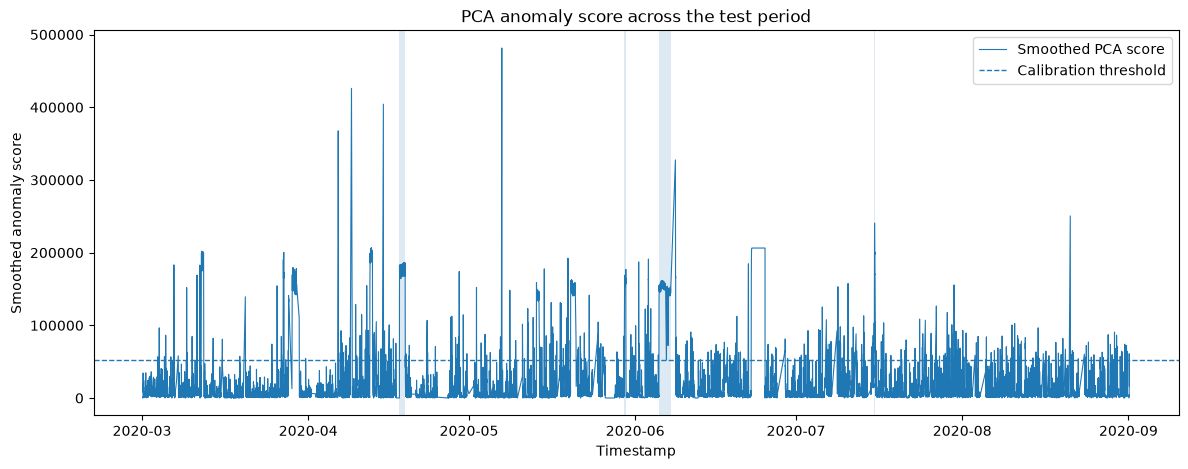

In [7]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    test_smoothed.index,
    test_smoothed.to_numpy(),
    linewidth=0.8,
    label="Smoothed PCA score",
)

ax.axhline(
    threshold,
    linestyle="--",
    linewidth=1.0,
    label="Calibration threshold",
)

for incident in incidents:
    start = pd.Timestamp(incident["start"])
    end = pd.Timestamp(incident["end"])

    start_num = float(
        mdates.date2num(
            start.to_pydatetime()
        )
    )
    end_num = float(
        mdates.date2num(
            end.to_pydatetime()
        )
    )

    ax.axvspan(
        start_num,
        end_num,
        alpha=0.15,
    )

ax.set_title(
    "PCA anomaly score across the test period"
)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Smoothed anomaly score")
ax.legend()
plt.show()

## Link alert episodes to documented incidents

For benchmark consistency, an alert episode is **incident-linked** when it overlaps the Phase 2 relevance interval:

$$
[\text{incident start}-24h,\ \text{incident end}]
$$

An episode outside every relevance interval is a benchmark false episode.

For each documented incident, we explain the first alert episode whose **start time** is inside the Phase 2 timely window:

$$
[\text{incident start}-24h,\ \text{incident start}+2h]
$$

This matches the event-level timing definition used in Phase 2.

In [8]:
early_window = pd.to_timedelta(
    int(
        evaluation_config[
            "early_warning_hours"
        ]
    ),
    unit="h",
)

late_window = pd.to_timedelta(
    int(
        evaluation_config[
            "late_tolerance_hours"
        ]
    ),
    unit="h",
)


def episode_is_relevant(
    episode: Any,
) -> bool:
    for incident in incidents:
        start = pd.Timestamp(incident["start"])
        end = pd.Timestamp(incident["end"])

        if (
            episode.start <= end
            and episode.end >= start - early_window
        ):
            return True

    return False


relevant_episodes = [
    episode
    for episode in episodes
    if episode_is_relevant(episode)
]

false_episodes = [
    episode
    for episode in episodes
    if not episode_is_relevant(episode)
]

print(
    "Incident-linked episodes:",
    len(relevant_episodes),
)
print(
    "Benchmark false episodes:",
    len(false_episodes),
)

Incident-linked episodes: 9
Benchmark false episodes: 133


## Explain the first timely alert episode for each incident

In [9]:
def first_timely_episode(
    incident: dict[str, Any],
) -> Any | None:
    start = pd.Timestamp(incident["start"])

    timely_start = start - early_window
    timely_end = start + late_window

    candidates = [
        episode
        for episode in episodes
        if (
            timely_start
            <= episode.start
            <= timely_end
        )
    ]

    if not candidates:
        return None

    return min(
        candidates,
        key=lambda episode: episode.start,
    )


def top_contributions_at(
    timestamp: pd.Timestamp,
    *,
    top_n: int = 5,
) -> tuple[
    list[dict[str, Any]],
    list[dict[str, Any]],
]:
    feature_row = (
        row_at_timestamp(
            normalized_smoothed_feature_contributions,
            timestamp,
        )
        .sort_values(
            ascending=False
        )
        .head(top_n)
    )

    group_row = (
        row_at_timestamp(
            normalized_smoothed_group_contributions,
            timestamp,
        )
        .sort_values(
            ascending=False
        )
        .head(top_n)
    )

    top_features = [
        {
            "feature": str(name),
            "share": float(value),
        }
        for name, value in feature_row.items()
    ]

    top_groups = [
        {
            "group": str(name),
            "share": float(value),
        }
        for name, value in group_row.items()
    ]

    return top_features, top_groups


incident_explanations = []

for incident in incidents:
    start = pd.Timestamp(incident["start"])
    end = pd.Timestamp(incident["end"])

    episode = first_timely_episode(incident)

    if episode is None:
        incident_explanations.append(
            {
                "id": incident["id"],
                "incident_start": str(start),
                "incident_end": str(end),
                "explanation_timestamp": None,
                "timing": "not_detected_in_timely_window",
                "lead_hours": None,
                "delay_hours": None,
                "raw_score": None,
                "smoothed_score": None,
                "top_features": [],
                "top_groups": [],
            }
        )
        continue

    timestamp = pd.Timestamp(episode.start)

    difference_hours = (
        (start - timestamp).total_seconds()
        / 3600.0
    )

    if difference_hours >= 0:
        timing = "pre_onset"
        lead_hours = difference_hours
        delay_hours = None
    else:
        timing = "post_onset"
        lead_hours = None
        delay_hours = -difference_hours

    top_features, top_groups = (
        top_contributions_at(
            timestamp,
            top_n=5,
        )
    )

    incident_explanations.append(
        {
            "id": incident["id"],
            "incident_start": str(start),
            "incident_end": str(end),
            "explanation_timestamp": str(timestamp),
            "timing": timing,
            "lead_hours": lead_hours,
            "delay_hours": delay_hours,
            "raw_score": float(
                explanation.score.loc[timestamp]
            ),
            "smoothed_score": float(
                test_smoothed.loc[timestamp]
            ),
            "top_features": top_features,
            "top_groups": top_groups,
        }
    )

incident_summary = pd.DataFrame(
    [
        {
            "incident_id": item["id"],
            "timestamp": item["explanation_timestamp"],
            "timing": item["timing"],
            "lead_hours": item["lead_hours"],
            "delay_hours": item["delay_hours"],
            "top_group": (
                item["top_groups"][0]["group"]
                if item["top_groups"]
                else None
            ),
            "top_group_share": (
                item["top_groups"][0]["share"]
                if item["top_groups"]
                else None
            ),
        }
        for item in incident_explanations
    ]
)

incident_summary

,incident_id,timestamp,timing,lead_hours,delay_hours,top_group,top_group_share
0,1,2020-04-18 00:40:00,post_onset,NaN,0.666667,tp2,0.939716
1,2,2020-05-29 21:20:00,pre_onset,2.166667,NaN,dv_pressure,0.775629
2,3,2020-06-05 10:10:00,post_onset,NaN,0.166667,tp2,0.860727
3,4,2020-07-15 08:45:00,pre_onset,5.750000,NaN,dv_pressure,0.744966


## Incident explanation plots

Each chart shows the operator-level signal groups contributing most strongly to the **smoothed PCA alert score** at the first timely alert episode start.

These bars describe anomaly evidence, not confirmed root cause.

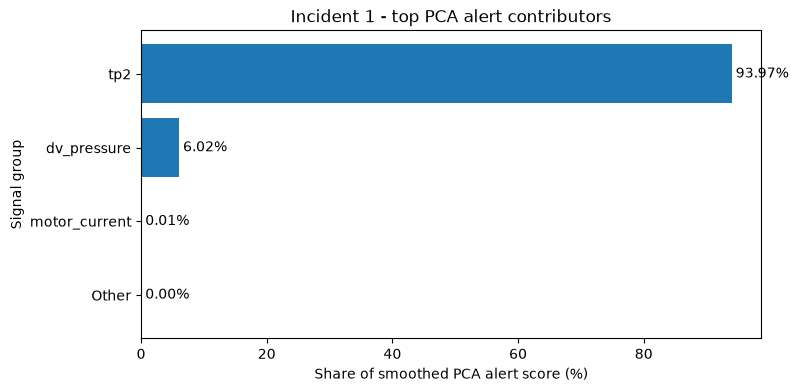

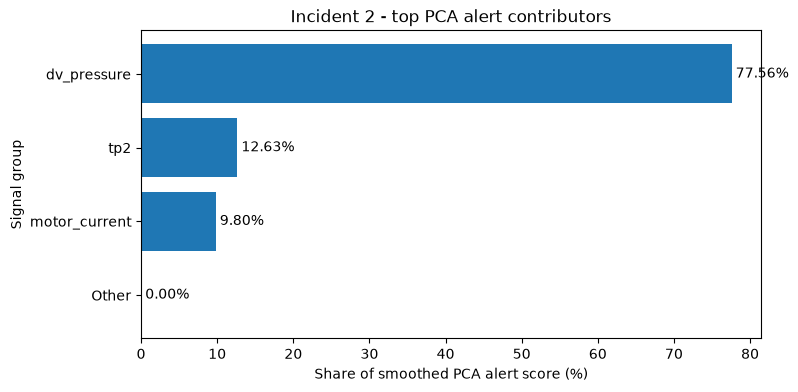

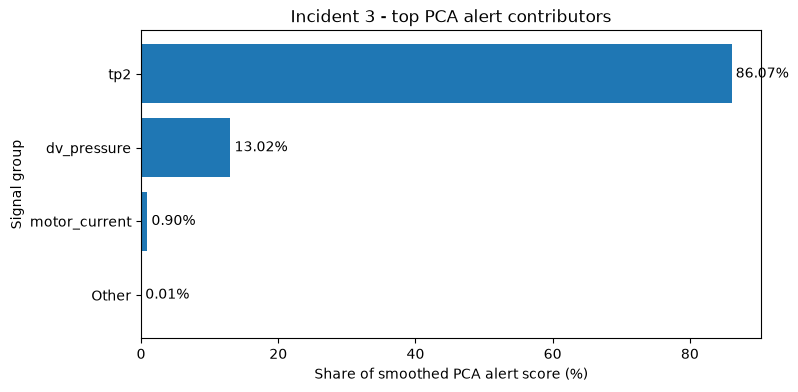

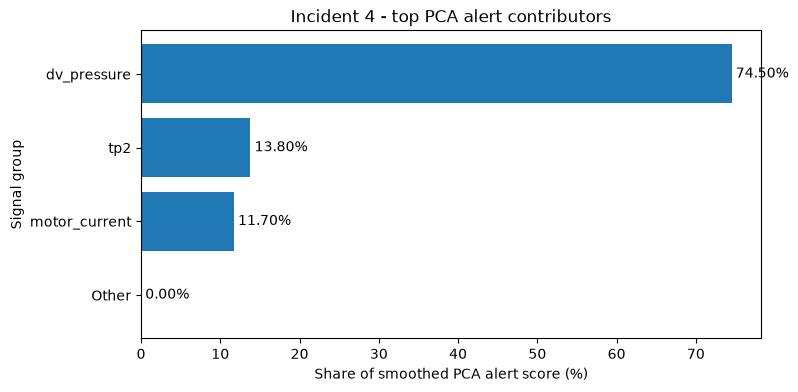

In [10]:
def compact_group_plot(
    timestamp: pd.Timestamp,
    *,
    top_n: int = 3,
) -> pd.DataFrame:
    row = (
        row_at_timestamp(
            normalized_smoothed_group_contributions,
            timestamp,
        )
        .sort_values(
            ascending=False
        )
    )

    top = (
        row
        .head(top_n)
        .rename("share")
        .reset_index()
        .rename(
            columns={
                "index": "group",
            }
        )
    )

    other_share = float(
        row.iloc[top_n:].sum()
    )

    if other_share > 0.0:
        top = pd.concat(
            [
                top,
                pd.DataFrame(
                    {
                        "group": ["Other"],
                        "share": [other_share],
                    }
                ),
            ],
            ignore_index=True,
        )

    return top


for item in incident_explanations:
    timestamp_text = item[
        "explanation_timestamp"
    ]

    if timestamp_text is None:
        continue

    timestamp = pd.Timestamp(
        timestamp_text
    )

    plot_frame = (
        compact_group_plot(
            timestamp,
            top_n=3,
        )
        .sort_values(
            "share",
            ascending=True,
        )
    )

    fig, ax = plt.subplots(
        figsize=(8, 4)
    )

    bars = ax.barh(
        plot_frame["group"],
        plot_frame["share"]
        * 100.0,
    )

    ax.bar_label(
        bars,
        fmt="%.2f%%",
        padding=3,
    )

    ax.set_title(
        f"Incident {item['id']} - "
        "top PCA alert contributors"
    )

    ax.set_xlabel(
        "Share of smoothed PCA "
        "alert score (%)"
    )

    ax.set_ylabel(
        "Signal group"
    )

    plt.show()

## Compare incident-linked and benchmark false alert evidence

The comparison below uses only bins where the alert flag is active.

“Benchmark false” means that the alert episode does not overlap any documented incident relevance interval. It does not prove that nothing abnormal occurred in the physical system at that time.

In [11]:
def alert_mask_for_episodes(
    selected_episodes: list[Any],
) -> pd.Series:
    mask = pd.Series(
        False,
        index=alerts.index,
        dtype=bool,
    )

    for episode in selected_episodes:
        inside_episode = (
            (mask.index >= episode.start)
            & (mask.index <= episode.end)
        )

        mask.loc[inside_episode] |= (
            alerts.loc[inside_episode]
        )

    return mask


relevant_alert_mask = alert_mask_for_episodes(
    relevant_episodes
)

false_alert_mask = alert_mask_for_episodes(
    false_episodes
)

relevant_group_mean = (
    normalized_smoothed_group_contributions
    .loc[relevant_alert_mask]
    .mean(axis=0)
    .sort_values(ascending=False)
)

false_group_mean = (
    normalized_smoothed_group_contributions
    .loc[false_alert_mask]
    .mean(axis=0)
    .sort_values(ascending=False)
)

comparison_groups = (
    pd.concat(
        [
            relevant_group_mean.rename(
                "incident_linked"
            ),
            false_group_mean.rename(
                "benchmark_false"
            ),
        ],
        axis=1,
    )
    .fillna(0.0)
)

comparison_groups.head(10)

,incident_linked,benchmark_false
tp2,9.084225e-01,0.845157
dv_pressure,8.783732e-02,0.136967
motor_current,3.687993e-03,0.017818
h1,2.679199e-05,0.000022
pressure_relationships,1.145007e-05,0.000011
oil_temperature,8.400902e-06,0.000008
towers,2.823939e-06,0.000004
reservoirs,1.161695e-06,0.000003
tp3,1.156700e-06,0.000003
dv_electric,1.104198e-07,0.000002


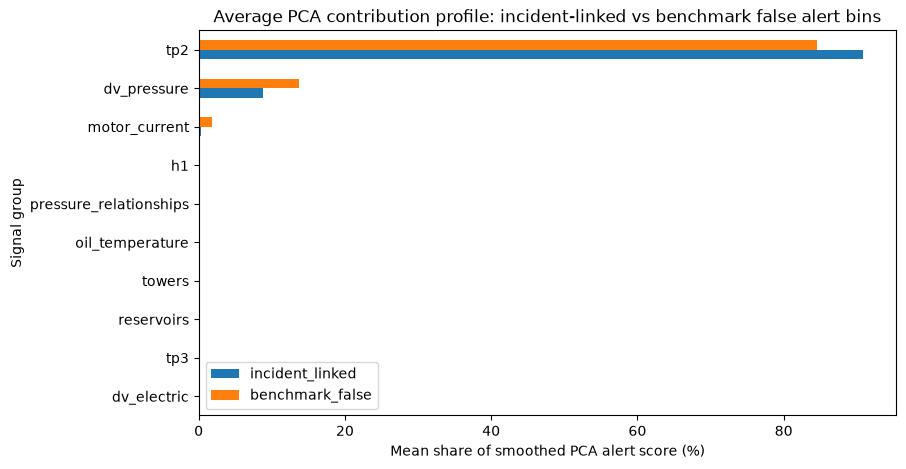

In [12]:
top_comparison_groups = (
    comparison_groups
    .max(axis=1)
    .sort_values(ascending=False)
    .head(10)
    .index
)

comparison_plot = (
    comparison_groups
    .loc[top_comparison_groups]
    .sort_values(
        "incident_linked",
        ascending=True,
    )
)

fig, ax = plt.subplots(
    figsize=(9, 5)
)

comparison_plot.mul(100.0).plot.barh(
    ax=ax
)

ax.set_title(
    "Average PCA contribution profile: "
    "incident-linked vs benchmark false alert bins"
)
ax.set_xlabel(
    "Mean share of smoothed PCA alert score (%)"
)
ax.set_ylabel("Signal group")

plt.show()

## Explanation concentration

This measures whether each incident explanation is dominated by a small number of signal groups or spread across many groups.

We report the cumulative share of the top 1, top 3, and top 5 groups at each incident explanation timestamp.

In [13]:
concentration_rows = []

for item in incident_explanations:
    timestamp_text = item[
        "explanation_timestamp"
    ]

    if timestamp_text is None:
        continue

    timestamp = pd.Timestamp(
        timestamp_text
    )

    ordered = (
        row_at_timestamp(
            normalized_smoothed_group_contributions,
            timestamp,
        )
        .sort_values(
            ascending=False
        )
    )

    concentration_rows.append(
        {
            "incident_id": item["id"],
            "top_1_share": float(
                ordered.head(1).sum()
            ),
            "top_3_share": float(
                ordered.head(3).sum()
            ),
            "top_5_share": float(
                ordered.head(5).sum()
            ),
        }
    )

concentration_frame = pd.DataFrame(
    concentration_rows
)

concentration_frame

,incident_id,top_1_share,top_3_share,top_5_share
0,1,0.939716,0.999957,0.999990
1,2,0.775629,0.999978,0.999995
2,3,0.860727,0.999947,0.999986
3,4,0.744966,0.999971,0.999993


## PCA structure sanity check

These tables inspect which engineered features dominate the retained principal components. This is a diagnostic for model interpretation, not a new model-selection step.

In [14]:
loading_columns = [
    f"PC{index + 1}"
    for index in range(
        int(
            detector.model.n_components_
        )
    )
]

loadings = pd.DataFrame(
    detector.model.components_.T,
    index=feature_columns,
    columns=loading_columns,
)

loading_rows = []

for component in loading_columns:
    component_values = (
        loadings[component]
        .abs()
        .sort_values(
            ascending=False
        )
        .head(10)
    )

    for feature, magnitude in (
        component_values.items()
    ):
        loading_rows.append(
            {
                "component":
                    component,
                "feature":
                    str(feature),
                "absolute_loading":
                    float(magnitude),
            }
        )

loading_summary = pd.DataFrame(
    loading_rows
)

loading_summary

,component,feature,absolute_loading
0,PC1,tp2__std,0.895566
1,PC1,tp2__max,0.386619
2,PC1,tp2__last,0.175358
3,PC1,tp2__mean,0.115667
4,PC1,dv_pressure__std,0.047652
5,PC1,motor_current__min,0.042887
6,PC1,dv_pressure__max,0.014169
7,PC1,tp2_minus_tp3__std,0.004541
8,PC1,h1__std,0.004480
9,PC1,h1__min,0.001417


## Physical feature context at incident alerts

For the strongest contributing engineered features, compare the incident-alert value with its training distribution. This helps distinguish a physically unusual signal from a purely numerical PCA artifact.

In [15]:
physical_context_rows = []

for item in incident_explanations:
    timestamp_text = item[
        "explanation_timestamp"
    ]

    if timestamp_text is None:
        continue

    timestamp = pd.Timestamp(
        timestamp_text
    )

    test_row = row_at_timestamp(
        test,
        timestamp,
    )

    for feature_item in (
        item["top_features"][:3]
    ):
        feature = feature_item[
            "feature"
        ]

        training_values = (
            train[feature]
            .astype(float)
        )

        q1 = float(
            training_values.quantile(
                0.25
            )
        )

        median = float(
            training_values.median()
        )

        q3 = float(
            training_values.quantile(
                0.75
            )
        )

        iqr = q3 - q1

        value = float(
            test_row[feature]
        )

        iqr_distance = (
            (value - median) / iqr
            if iqr > 0.0
            else None
        )

        physical_context_rows.append(
            {
                "incident_id":
                    item["id"],
                "timestamp":
                    str(timestamp),
                "feature":
                    feature,
                "value":
                    value,
                "training_q1":
                    q1,
                "training_median":
                    median,
                "training_q3":
                    q3,
                "iqr_distance":
                    iqr_distance,
            }
        )

physical_context = pd.DataFrame(
    physical_context_rows
)

physical_context

,incident_id,timestamp,feature,value,training_q1,training_median,training_q3,iqr_distance
0,1,2020-04-18 00:40:00,tp2__mean,8.815355,-0.012129,-0.010800,-0.008533,2454.642344
1,1,2020-04-18 00:40:00,tp2__min,7.616000,-0.016000,-0.014000,-0.012000,1907.500000
2,1,2020-04-18 00:40:00,tp2__max,9.096000,-0.010000,-0.008000,-0.006000,2276.000000
3,2,2020-05-29 21:20:00,dv_pressure__std,0.000860,0.000792,0.000932,0.001008,-0.333140
4,2,2020-05-29 21:20:00,motor_current__min,0.042500,0.035000,0.035000,0.037500,3.000000
5,2,2020-05-29 21:20:00,dv_pressure__last,-0.020000,-0.020000,-0.018000,-0.016000,-0.500000
6,3,2020-06-05 10:10:00,tp2__mean,8.030774,-0.012129,-0.010800,-0.008533,2236.442584
7,3,2020-06-05 10:10:00,tp2__min,6.318000,-0.016000,-0.014000,-0.012000,1583.000000
8,3,2020-06-05 10:10:00,tp2__max,8.446000,-0.010000,-0.008000,-0.006000,2113.500000
9,4,2020-07-15 08:45:00,dv_pressure__std,0.001126,0.000792,0.000932,0.001008,0.901307


## Write the XAI evidence report

`docs/xai_report.json` records the explanation protocol and incident-level evidence for later API/UI work.

Terminology is deliberately conservative:
- contribution = signal contribution to the anomaly score;
- incident-linked = alert timing overlaps the benchmark incident relevance interval;
- no PCA contribution is treated as proof of physical root cause or causality.

In [16]:
def series_top_records(
    series: pd.Series,
    *,
    top_n: int = 10,
    key_name: str = "group",
) -> list[dict[str, Any]]:
    return [
        {
            key_name: str(name),
            "share": float(value),
        }
        for name, value
        in (
            series
            .sort_values(ascending=False)
            .head(top_n)
            .items()
        )
    ]


report = {
    "detector": {
        "name": "pca_reconstruction",
        "variance_retained": variance_retained,
        "components": int(
            detector.model.n_components_
        ),
        "explained_variance_ratio": float(
            detector.model
            .explained_variance_ratio_
            .sum()
        ),
        "feature_count": len(feature_columns),
    },
    "alerting": {
        "threshold": threshold,
        "threshold_quantile": float(
            alert_config["threshold_quantile"]
        ),
        "ewma_alpha": float(
            alert_config["ewma_alpha"]
        ),
        "persistence_hits": int(
            alert_config["persistence_hits"]
        ),
        "persistence_window": int(
            alert_config["persistence_window"]
        ),
    },
    "explanation": {
        "basis": (
            "squared PCA reconstruction residual "
            "in robust-scaled feature space, "
            "propagated through the same causal "
            "EWMA used by the alert pipeline"
        ),
        "score_identity": (
            "smoothed_score = "
            "sum(smoothed_feature_contributions)"
        ),
        "feature_grouping": (
            "engineered feature statistics are "
            "aggregated into operator-level signal groups"
        ),
        "causal_claim": False,
        "interpretation": (
            "Contributions identify signals associated "
            "with anomaly evidence, not confirmed root cause."
        ),
    },
    "episodes": {
        "total": len(episodes),
        "incident_linked": len(
            relevant_episodes
        ),
        "benchmark_false": len(
            false_episodes
        ),
    },
    "incidents": incident_explanations,
    "concentration": concentration_rows,
    "diagnostics": {
        "pca_loadings":
            loading_rows,
        "physical_context":
            physical_context_rows,
    },
    "global_profiles": {
        "incident_linked_top_groups":
            series_top_records(
                relevant_group_mean
            ),
        "benchmark_false_top_groups":
            series_top_records(
                false_group_mean
            ),
    },
}

REPORT_PATH.parent.mkdir(
    parents=True,
    exist_ok=True,
)

REPORT_PATH.write_text(
    json.dumps(
        report,
        indent=2,
    ),
    encoding="utf-8",
)

print(
    f"XAI report written to: {REPORT_PATH}"
)

XAI report written to: /mnt/c/Users/Dell ProMax Tower T2/Downloads/code/xAI-Compressor/docs/xai_report.json


## Interpretation checklist

When using these results in the AeroXAI interface or ESIC presentation:

**Supported**
- “Motor-current-related features contributed X% of the smoothed PCA alert score.”
- “The strongest abnormal signal groups were TP2, DV pressure, and motor current.”
- “This incident-linked alert had a concentrated or diffuse contribution profile.”

**Not supported**
- “Motor current caused the failure.”
- “PCA identified the physical root cause.”
- “A high contribution proves a component is faulty.”

Root-cause confirmation would require additional engineering evidence, maintenance records, component-level labels, or causal/diagnostic validation beyond this dataset.